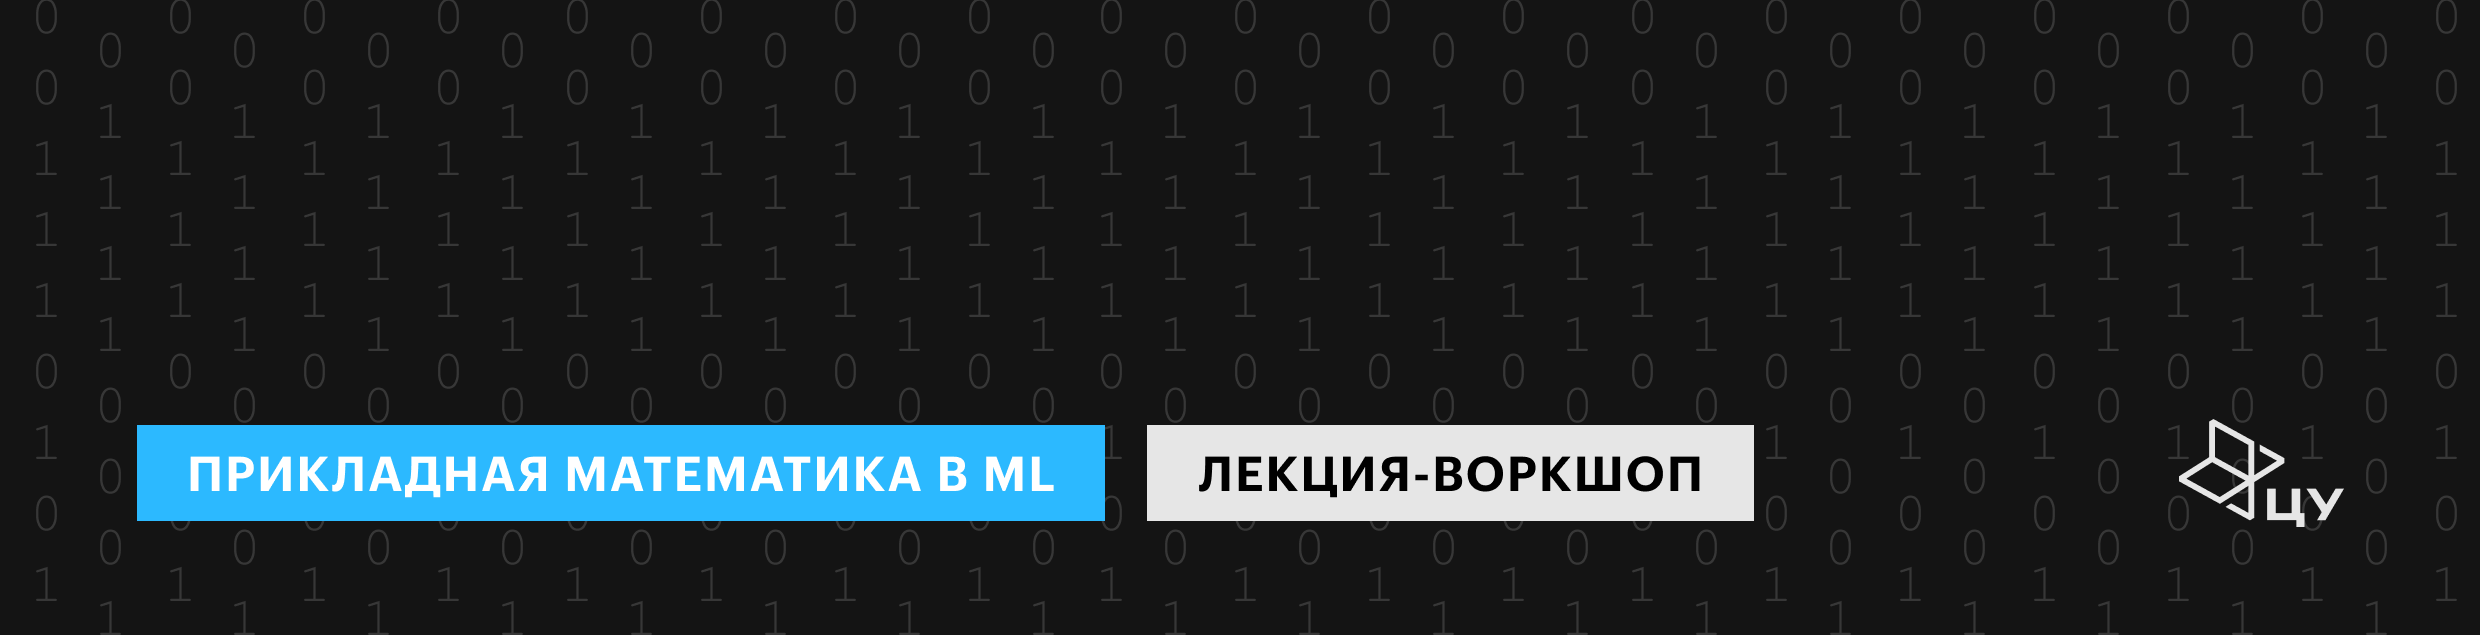

# Неделя 1. Матрицы и векторы (начало)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

### Картинка = набор матриц

Дана картинка.

Переведите её в grayscale по формуле

$GS = 0.299R + 0.587G + 0.114B$.

In [ ]:
! gdown 16xwOW1bO06sIIbbVlwtXpUD1De6-W1XI

Downloading...
From: https://drive.google.com/uc?id=16xwOW1bO06sIIbbVlwtXpUD1De6-W1XI
To: /content/kotik.jpg
100% 118k/118k [00:00<00:00, 30.3MB/s]


In [ ]:
from PIL import Image

In [ ]:
img = Image.open("/content/kotik.jpg")

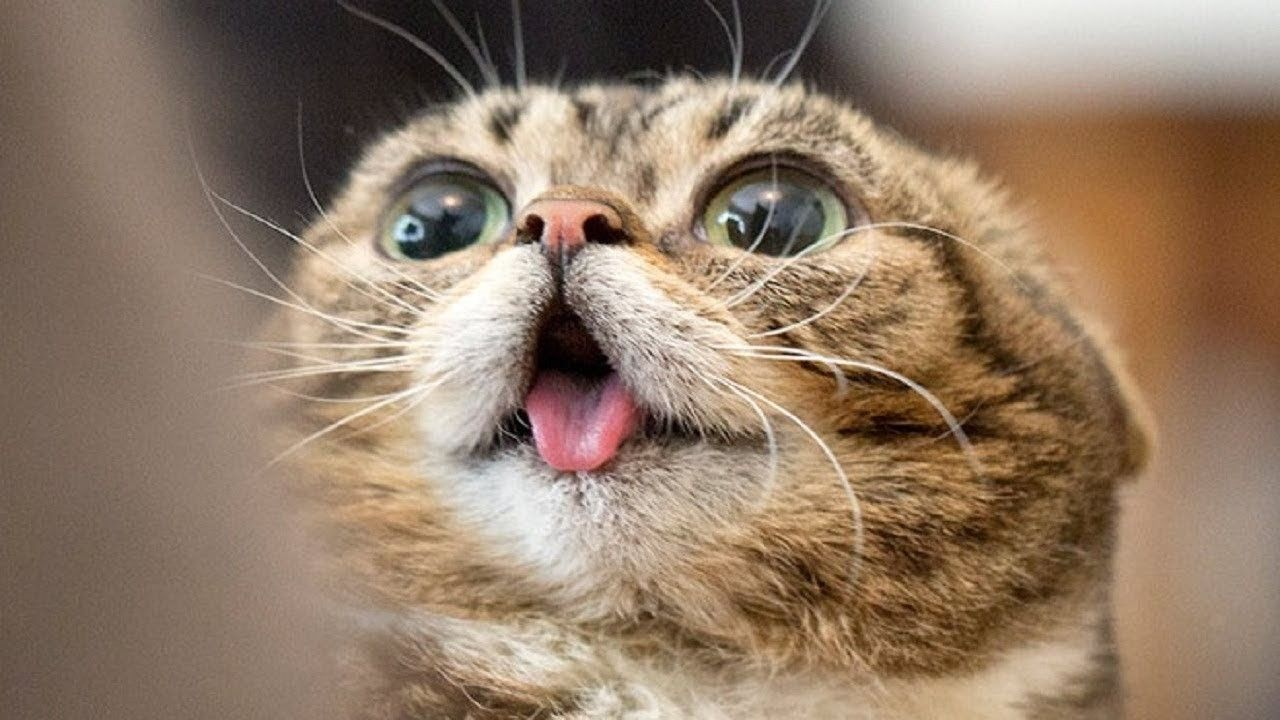

In [ ]:
img

In [ ]:
img_array = np.array(img)
img_array

array([[[123, 104,  90],
        [117,  98,  84],
        [117,  98,  84],
        ...,
        [230, 232, 229],
        [230, 232, 229],
        [230, 232, 229]],

       [[121, 102,  88],
        [116,  97,  83],
        [117,  98,  84],
        ...,
        [230, 232, 229],
        [230, 232, 229],
        [230, 232, 229]],

       [[118,  99,  85],
        [114,  95,  81],
        [117,  98,  84],
        ...,
        [229, 231, 228],
        [229, 231, 228],
        [229, 231, 228]],

       ...,

       [[ 99,  81,  67],
        [ 99,  81,  67],
        [100,  82,  68],
        ...,
        [107,  96,  94],
        [106,  95,  93],
        [106,  95,  93]],

       [[ 99,  81,  67],
        [ 99,  81,  67],
        [100,  82,  68],
        ...,
        [107,  96,  94],
        [106,  95,  93],
        [106,  95,  93]],

       [[ 99,  81,  67],
        [ 99,  81,  67],
        [100,  82,  68],
        ...,
        [107,  96,  94],
        [106,  95,  93],
        [106,  95,  93]]

Посмотрим на размерность.

In [ ]:
img_array.shape # в RGB

(720, 1280, 3)

Посмотрим на слои по отдельности.

In [ ]:
img_array[:, :, 0]

array([[123, 117, 117, ..., 230, 230, 230],
       [121, 116, 117, ..., 230, 230, 230],
       [118, 114, 117, ..., 229, 229, 229],
       ...,
       [ 99,  99, 100, ..., 107, 106, 106],
       [ 99,  99, 100, ..., 107, 106, 106],
       [ 99,  99, 100, ..., 107, 106, 106]], dtype=uint8)

В NumPy можно копировать массивы и присваивать отдельные значения в матрицах с помощью индексации.

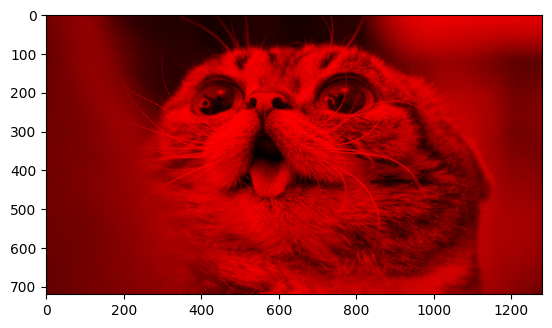

In [ ]:
new_img = img_array.copy()
new_img[:, :, 1:] = 0
plt.imshow(new_img, vmin=0, vmax=255)

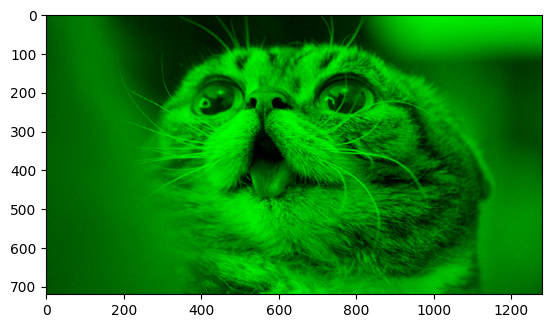

In [ ]:
new_img = img_array.copy()
new_img[:, :, [0, 2]] = 0
plt.imshow(new_img, vmin=0, vmax=255)

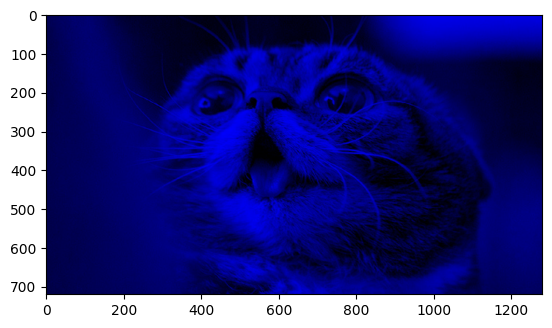

In [ ]:
new_img = img_array.copy()
new_img[:, :, :2] = 0
plt.imshow(new_img, vmin=0, vmax=255)

Переведём в grayscale.

In [ ]:
gs = img_array[:, :, 0] * 0.299 + img_array[:, :, 1] * 0.587 + img_array[:, :, 2] * 0.114

In [ ]:
gs

array([[108.085, 102.085, 102.085, ..., 231.06 , 231.06 , 231.06 ],
       [106.085, 101.085, 102.085, ..., 231.06 , 231.06 , 231.06 ],
       [103.085,  99.085, 102.085, ..., 230.06 , 230.06 , 230.06 ],
       ...,
       [ 84.786,  84.786,  85.786, ...,  99.061,  98.061,  98.061],
       [ 84.786,  84.786,  85.786, ...,  99.061,  98.061,  98.061],
       [ 84.786,  84.786,  85.786, ...,  99.061,  98.061,  98.061]])

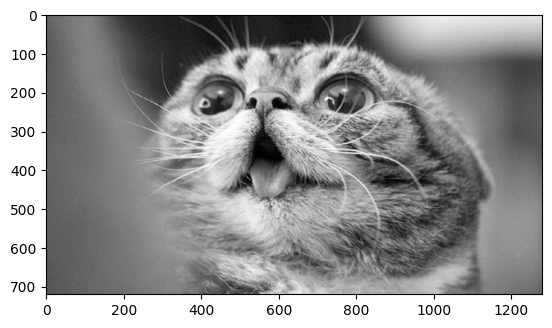

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(gs,cmap='gray', vmin=0, vmax=255)

### Тексты = набор векторов

In [ ]:
from sentence_transformers import SentenceTransformer

Загрузим предобученную модель.

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Придумаем набор текстов.

In [ ]:
texts = [
    "кошка сидит на коврике",
    "собака бежит по двору",
    "кошка и собака играют вместе",
    "на коврике спит пушистый кот",
    "во дворе громко лает собака"
]

Получим эмбеддинги: каждый текст —> вектор размерности 384.

In [ ]:
embeddings = model.encode(texts, convert_to_numpy=True)

Посмотрим на размер матрицы эмбеддингов и вид вектора первого текста.

In [ ]:
print("Размер матрицы эмбеддингов:", embeddings.shape)
print("Вектор первого текста:", embeddings[:][:10])

Размер матрицы эмбеддингов: (5, 384)
Вектор первого текста: [[-0.00569627  0.09205527 -0.01930163 ...  0.01318322 -0.00911765
  -0.01015809]
 [ 0.04502296  0.15228875 -0.04695635 ...  0.03631126 -0.0022868
  -0.08128305]
 [ 0.06013057  0.12422015 -0.04246464 ...  0.03430183  0.00679601
  -0.02040803]
 [-0.02017495  0.03550196 -0.03769091 ...  0.04037018  0.02774606
   0.02115807]
 [ 0.05264506  0.15536119 -0.02966026 ...  0.09181198  0.01302908
  -0.074448  ]]


## Быстродействие NumPy

За счёт чего `NumPy` работает быстрее самописных реализаций?

* Значительная часть кода **написана на C**.
* Базовым классом является `ndarray`, имеющий следующие отличия от списков.
    * У него **фиксированная длина**, задаваемая в момент его создания (в отличие от списков в `Python`, которые могут менять размер динамически и хранятся на непрерывном участке памяти).
    * Все элементы в нём имеют только **один тип** (в отличие от списков в `Python`, в которые можно положить несколько объектов разного типа).


* `NumPy` можно подключить к высокооптимизированным **библиотекам** для матричной алгебры (BLAS, LAPACK, Intel MKL).

* Часть матричных операций может быть **распараллелена** при наличии в системе нескольких потоков.

-----------

Реализуем матричное умножение на чистом Python и сравним с матричным умножением на NumPy.

In [ ]:
def matrix_transpose_py(A):
    # A — размера n × m
    n, m = len(A), len(A[0])

    C = [[0] * n for _ in range(m)]

    for i in range(n):
        for j in range(m):
            C[j][i] = A[i][j]

    return C


def matrix_dot_py(A, B):
    # A — размера n × m
    # B — размера m × k

    def dot(x, y):
        return sum(i * j for (i, j) in zip(x, y))

    n, m, k = len(A), len(A[0]), len(B[0])
    C = [[0] * k for _ in range(n)]

    B_t = matrix_transpose_py(B)
    for i in range(n):
        for j in range(k):
            C[i][j] = dot(A[i], B_t[j])
    return C

Сгенерируем большие данные и попробуем измерить время работы самописных операций и их же реализаций в `NumPy`.

In [ ]:
import random

n, m, k = 1000, 70, 50

lst1 = [[random.random() for _ in range(m)] for _ in range(n)]
lst2 = [[random.random() for _ in range(k)] for _ in range(m)]

Измерим время работы ячейки с помощью магической функции в %%time.


In [ ]:
%%time

for i in range(10):
    _ = matrix_dot_py(lst1, lst2)

CPU times: user 2.98 s, sys: 5.19 ms, total: 2.99 s
Wall time: 3.01 s


То же самое на `NumPy`.

In [ ]:
%%time
lst1_np = np.array(lst1)
lst2_np = np.array(lst2)

for i in range(10):
    _ = np.array(lst1_np) @ np.array(lst2_np)

CPU times: user 15.7 ms, sys: 18 µs, total: 15.7 ms
Wall time: 11.1 ms


Отобразим время работы операции умножения в зависимости от размера матриц (две стороны зафиксируем). Здесь уже понадобится библиотека `time`.

In [ ]:
import time

In [ ]:
times_py = []
times_np = []
matrix_sizes = []
m, k = 70, 50  # Зафиксируем вторую матрицу
Ns = list(range(1, 100)) + list(np.linspace(100, 2000, 100, dtype=int))
# Числа от 1 до 99 + 100 чисел равномерно в диапазоне от 100 до 2000

for n in Ns:
    lst1 = [[random.random() for _ in range(m)] for _ in range(n)]
    lst2 = [[random.random() for _ in range(k)] for _ in range(m)]

    # Измеряем время сложения питоновской реализацией
    start = time.time()
    _ = matrix_dot_py(lst1, lst2)
    times_py.append(time.time() - start)

    # Измеряем время сложения реализацией на NumPy (без учёта создания массива)
    lst1_np = np.array(lst1)
    lst2_np = np.array(lst2)
    start = time.time()
    _ = np.array(lst1_np) @ np.array(lst2_np)
    times_np.append(time.time() - start)

    matrix_sizes.append(n)

In [ ]:
df1 = pd.DataFrame({'Реализация': ['Python'] * len(matrix_sizes),
                    'Размер матрицы': matrix_sizes,
                    'Время (сек)': times_py})
df2 = pd.DataFrame({'Реализация': ['Numpy'] * len(matrix_sizes),
                    'Размер матрицы': matrix_sizes,
                    'Время (сек)': times_np})
df = pd.concat([df1, df2])

px.line(df, x='Размер матрицы',y='Время (сек)', color='Реализация', markers=True, title='Сравнение времени работы матричного перемножения')

В общем-то, на графике выше видно, как `NumPy` обгоняет питоновскую реализацию, особенно на больших размерах.


-----------

# Задачи



## Задача 1

Даны два вектора: a и b.

Вычислите их линейную комбинацию с коэффициентам 5 и −2.

In [ ]:
a = np.array([1, 3, 5, 7])
b = np.array([2, 4, 6, 8])

### Решение

In [ ]:
# @title
c = 5 * a - 2 * b
c

array([ 1,  7, 13, 19])

## Задача 2

Дана матрица А.

Найдите:

* элемент во второй строке и третьем столбце (индексы: [1, 2]);
* вторую строку целиком;
* подматрицу из первых двух строк и последних двух столбцов.


In [ ]:
A = np.array([[10, 20, 30],
              [40, 50, 60],
              [70, 80, 90]])

### Решение

In [ ]:
# @title
element = A[1, 2]
row = A[1, :]
submatrix = A[:2, 1:]

element, row, submatrix

(np.int64(60),
 array([40, 50, 60]),
 array([[20, 30],
        [50, 60]]))

## Задача 3

Дана матрица А.

Найдите след матриц $AA^T$.

In [ ]:
A = np.array([[10, 20, 30],
              [40, 50, 60],
              [70, 80, 90]])

## Решение

In [ ]:
# @title
np.trace(A @ A.T)

np.int64(28500)

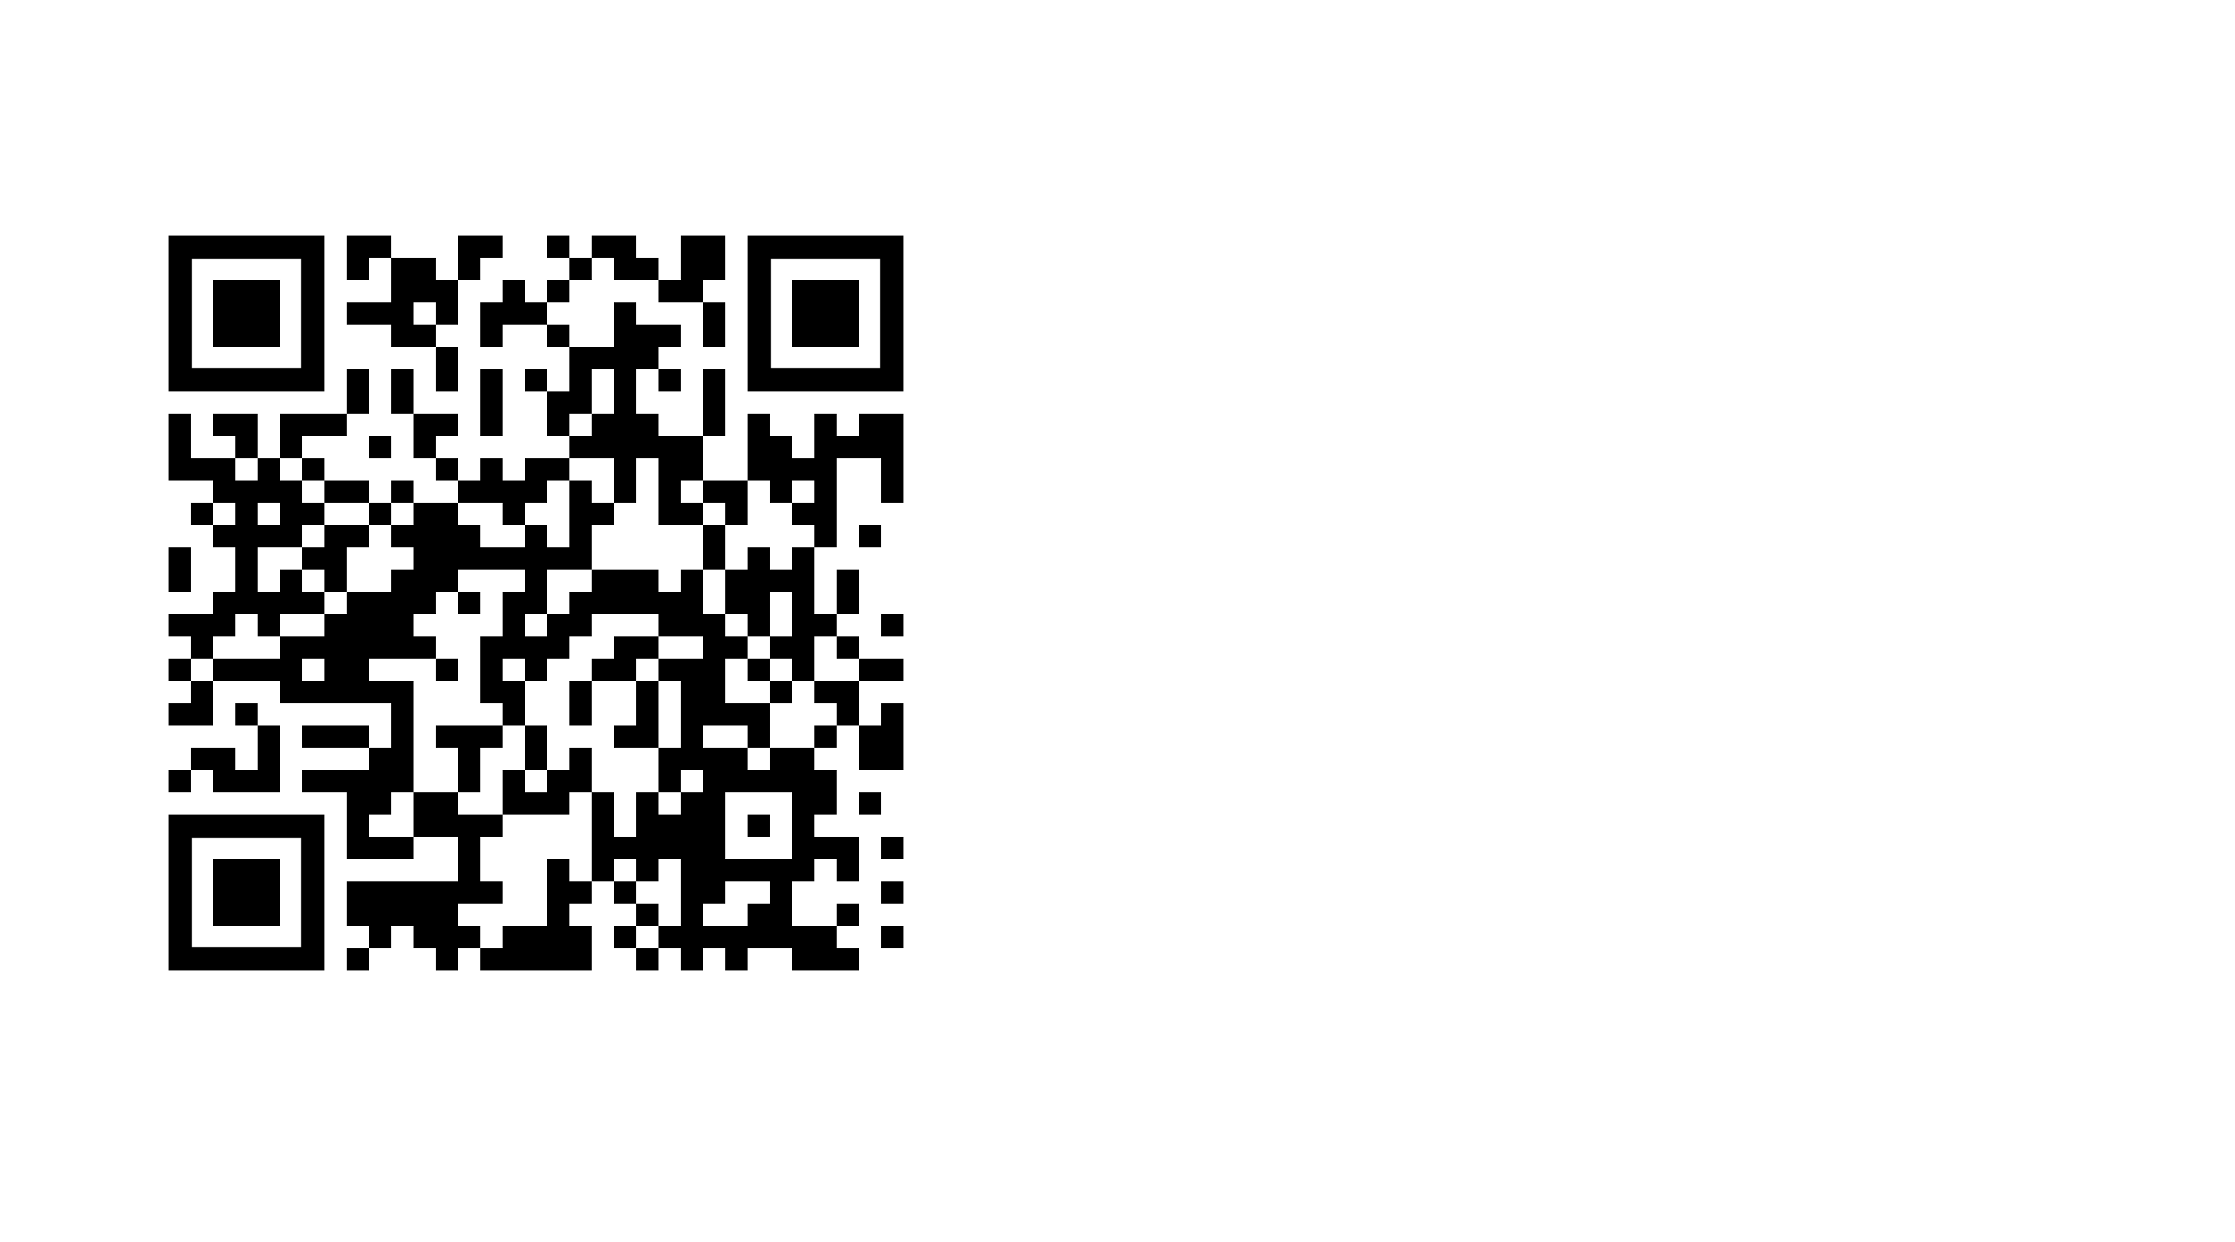